In [ ]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.warn('ignore')
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
df= pd.read_csv("/content/DataSetA.csv", names = ['products'], sep = ',')
df.head()

products
Lassi  Coffee Powder Butter        Yougurt       Ghee   Cheese NaN NaN NaN NaN      NaN
Ghee   Coffee Powder NaN           NaN           NaN    NaN    NaN NaN NaN NaN      NaN
Lassi  Tea Powder    Butter        Cheese        NaN    NaN    NaN NaN NaN NaN      NaN
Cheese Tea Powder    Panner        Coffee Powder Butter Bread  NaN NaN NaN NaN      NaN
       Yougurt       Coffee Powder Sugar         Butter Sweet  NaN NaN NaN NaN      NaN

In [ ]:
df.shape

(12526, 1)

In [ ]:
data = list(df["products"].apply(lambda x:x.split(",") ))
data

AttributeError: 'float' object has no attribute 'split'

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.replace(False,0)
df

NameError: name 'data' is not defined

In [ ]:
df = apriori(df, min_support = 0.2, use_colnames = True, verbose = 1)
df

Processing 42 combinations | Sampling itemset size 3


,support,itemsets
0,0.35,(BISCUIT)
1,0.2,(BOURNVITA)
2,0.65,(BREAD)
3,0.4,(COFFEE)
4,0.3,(CORNFLAKES)
5,0.25,(MAGGI)
6,0.25,(MILK)
7,0.3,(SUGER)
8,0.35,(TEA)
9,0.2,"(BREAD, BISCUIT)"


In [ ]:
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.6)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(MILK),(BREAD),0.25,0.65,0.2,0.800000,1.230769,0.0375,1.75,0.250000
1,(SUGER),(BREAD),0.30,0.65,0.2,0.666667,1.025641,0.0050,1.05,0.035714
2,(CORNFLAKES),(COFFEE),0.30,0.40,0.2,0.666667,1.666667,0.0800,1.80,0.571429
3,(SUGER),(COFFEE),0.30,0.40,0.2,0.666667,1.666667,0.0800,1.80,0.571429
4,(MAGGI),(TEA),0.25,0.35,0.2,0.800000,2.285714,0.1125,3.25,0.750000


array([[<Axes: title={'center': 'confidence'}>,
        <Axes: title={'center': 'lift'}>]], dtype=object)

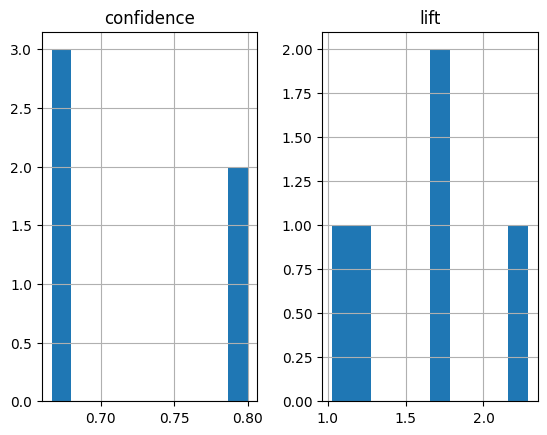

In [ ]:
# Convert columns to numerical data types if needed
df_ar['confidence'] = pd.to_numeric(df_ar['confidence'])
df_ar['lift'] = pd.to_numeric(df_ar['lift'])

# Now, you can use the hist method
df_ar[['confidence', 'lift']].hist()



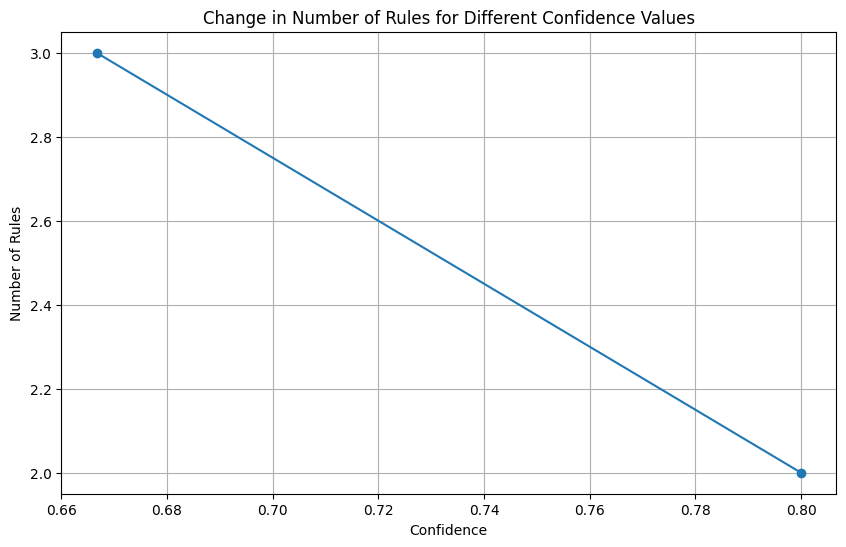

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame df_ar containing association rules with 'confidence' column

# Group association rules by confidence values and count the number of rules for each confidence value
confidence_counts = df_ar['confidence'].value_counts().sort_index()

# Plot the change in the number of rules for different confidence values
plt.figure(figsize=(10, 6))
plt.plot(confidence_counts.index, confidence_counts.values, marker='o', linestyle='-')
plt.title('Change in Number of Rules for Different Confidence Values')
plt.xlabel('Confidence')
plt.ylabel('Number of Rules')
plt.grid(True)
plt.show()


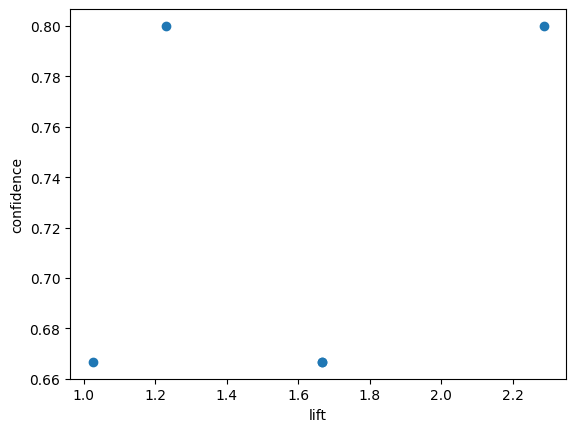

In [ ]:
 # visualization of association rule
plt.scatter(df_ar['lift'],df_ar['confidence'])
plt.xlabel('lift')
plt.ylabel('confidence')
plt.show()